# 06 - Multi-Horizon Early-Warning Modeling

This notebook upgrades the modeling branch from a single day-30 classifier into a **research-focused multi-horizon early-warning study**.

## Research questions
1. How early can the project identify at-risk learners with useful recall?
2. Which horizon-model pair offers the strongest trade-off between intervention lead time and predictive quality?
3. Which feature groups create most of the modeling value?
4. Are the predicted probabilities calibrated well enough to support risk-tiered intervention?

## Scope
- Horizons: `day 7`, `day 14`, `day 21`, `day 30`
- Models: `Logistic Regression`, `Random Forest`, `XGBoost`
- Threshold rule: keep `validation recall >= 0.90`, then maximize `precision`, then `F2`, then `PR-AUC`
- Champion rule: compare all horizon-model pairs primarily on `PR-AUC`, then `F2`, and prefer an earlier horizon only when performance is close

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 190)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'
sys.path.append(str(ROOT))

from src.models import run_multi_horizon_study

HORIZONS = (7, 14, 21, 30)
ROOT, PROCESSED

(PosixPath('/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project'),
 PosixPath('/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project/data/processed'))

## 1. Run the multi-horizon study

The heavy pipeline now lives in `src/models/multi_horizon_early_warning.py`.
The notebook remains responsible for the research narrative, visual checks, and reporting interpretation.

In [2]:
results = run_multi_horizon_study(
    processed_dir=PROCESSED,
    horizons=HORIZONS,
    ablation_horizons=(14, 30),
    random_state=42,
    target_recall=0.90,
    write_outputs=True,
)

display(results.split_summary)

print('Champion horizon-model pair:')
display(results.champion_row.to_frame(name='value'))

,split,rows,at_risk_rate
0,test,6519,0.5280
1,train,19555,0.5279
2,validation,6519,0.5280


Champion horizon-model pair:


,value
threshold,0.2500
accuracy,0.6710
precision,0.6278
recall,0.9253
f1,0.7481
f2,0.8452
roc_auc,0.8302
pr_auc,0.8639
brier_score,0.1664
tn,1189


## 2. Model comparison across horizons

A fair comparison needs the same enrollment split across all horizons.
That way, the differences below come from the **amount of information available by each day cutoff**, not from a moving test sample.

In [3]:
selected_cols = [
    'horizon_day', 'model', 'threshold', 'precision', 'recall', 'f2', 'roc_auc', 'pr_auc',
    'is_best_for_horizon', 'is_earliest_useful_horizon',
]
display(results.selected_operating_points[selected_cols].sort_values(['horizon_day', 'model']))

comparison_view = results.model_horizon_comparison[[
    'horizon_day', 'model', 'selected_threshold',
    'validation_precision', 'validation_recall', 'validation_f2', 'validation_pr_auc',
    'test_precision', 'test_recall', 'test_f2', 'test_pr_auc',
]].sort_values(['horizon_day', 'model'])
display(comparison_view)

,horizon_day,model,threshold,precision,recall,f2,roc_auc,pr_auc,is_best_for_horizon,is_earliest_useful_horizon
0,7,Logistic Regression,0.2500,0.5771,0.9393,0.8345,0.7376,0.7592,True,True
1,7,Random Forest,0.3000,0.5805,0.9250,0.8269,0.7334,0.7565,False,False
2,7,XGBoost,0.3000,0.5892,0.9035,0.8164,0.7408,0.7637,False,False
3,14,Logistic Regression,0.2500,0.5828,0.9259,0.8284,0.7584,0.7907,False,False
4,14,Random Forest,0.3000,0.5934,0.9143,0.8251,0.7568,0.7916,False,False
5,14,XGBoost,0.2500,0.5794,0.9372,0.8342,0.7666,0.8012,True,False
6,21,Logistic Regression,0.2500,0.6037,0.9169,0.8307,0.7752,0.8091,False,False
7,21,Random Forest,0.3000,0.6234,0.9024,0.8283,0.7977,0.8334,False,False
8,21,XGBoost,0.2500,0.6122,0.9311,0.8433,0.8094,0.8432,True,False
9,30,Logistic Regression,0.2500,0.6179,0.9102,0.8316,0.7936,0.8263,False,False


,horizon_day,model,selected_threshold,validation_precision,validation_recall,validation_f2,validation_pr_auc,test_precision,test_recall,test_f2,test_pr_auc
0,7,Logistic Regression,0.2500,0.5771,0.9393,0.8345,0.7592,0.5791,0.9451,0.8391,0.7730
1,7,Random Forest,0.3000,0.5805,0.9250,0.8269,0.7565,0.5873,0.9323,0.8343,0.7736
2,7,XGBoost,0.3000,0.5892,0.9035,0.8164,0.7637,0.5984,0.9166,0.8285,0.7770
3,14,Logistic Regression,0.2500,0.5828,0.9259,0.8284,0.7907,0.5909,0.9314,0.8352,0.8041
4,14,Random Forest,0.3000,0.5934,0.9143,0.8251,0.7916,0.6000,0.9204,0.8316,0.8066
5,14,XGBoost,0.2500,0.5794,0.9372,0.8342,0.8012,0.5853,0.9480,0.8435,0.8114
6,21,Logistic Regression,0.2500,0.6037,0.9169,0.8307,0.8091,0.6075,0.9332,0.8428,0.8214
7,21,Random Forest,0.3000,0.6234,0.9024,0.8283,0.8334,0.6314,0.9088,0.8354,0.8469
8,21,XGBoost,0.2500,0.6122,0.9311,0.8433,0.8432,0.6118,0.9404,0.8492,0.8543
9,30,Logistic Regression,0.2500,0.6179,0.9102,0.8316,0.8263,0.6221,0.9227,0.8414,0.8423


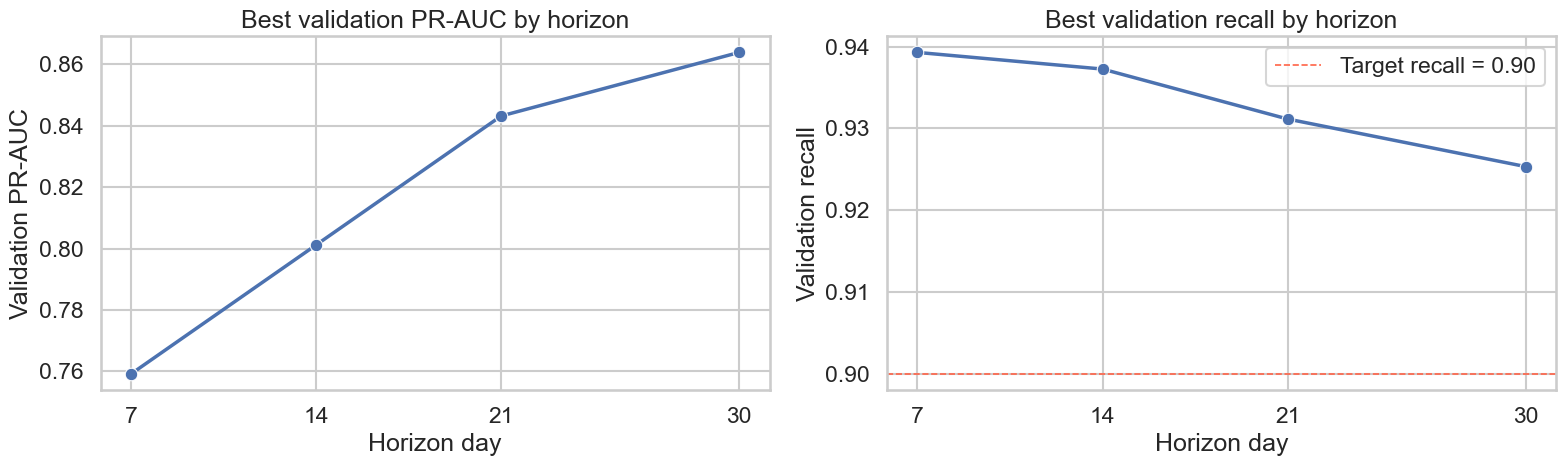

In [4]:
plot_df = results.model_horizon_comparison.copy()
best_only = plot_df.merge(
    results.selected_operating_points[['horizon_day', 'model', 'is_best_for_horizon']],
    on=['horizon_day', 'model'],
    how='left',
)
best_only = best_only.loc[best_only['is_best_for_horizon']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=best_only, x='horizon_day', y='validation_pr_auc', marker='o', linewidth=2.5, ax=axes[0])
axes[0].set_title('Best validation PR-AUC by horizon')
axes[0].set_xlabel('Horizon day')
axes[0].set_ylabel('Validation PR-AUC')
axes[0].set_xticks(list(HORIZONS))

sns.lineplot(data=best_only, x='horizon_day', y='validation_recall', marker='o', linewidth=2.5, ax=axes[1])
axes[1].axhline(0.90, color='tomato', linestyle='--', linewidth=1.2, label='Target recall = 0.90')
axes[1].set_title('Best validation recall by horizon')
axes[1].set_xlabel('Horizon day')
axes[1].set_ylabel('Validation recall')
axes[1].set_xticks(list(HORIZONS))
axes[1].legend()

plt.tight_layout()

## 3. Threshold tuning and the champion operating point

The project does **not** use the default `0.50` classification threshold.
Instead, each horizon-model pair gets its own validation-selected operating point under the recall-first rule.

,split,horizon_day,model,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,brier_score
0,validation,30,XGBoost,0.2500,0.6710,0.6278,0.9253,0.7481,0.8452,0.8302,0.8639,0.1664
1,test,30,XGBoost,0.2500,0.6777,0.6313,0.9367,0.7542,0.8540,0.8467,0.8766,0.1580


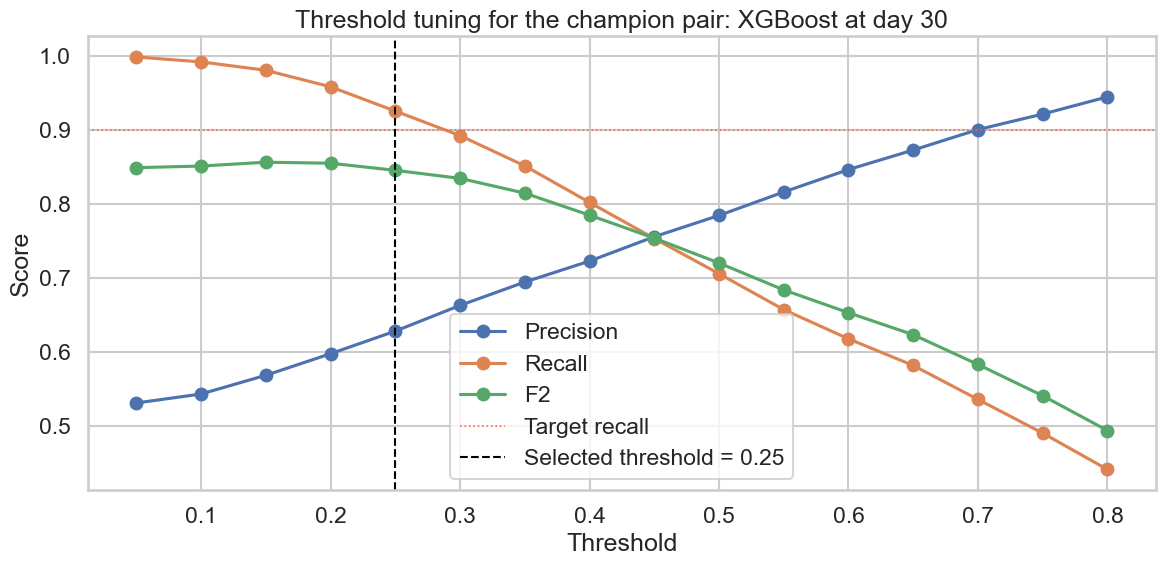

In [5]:
champion_horizon = int(results.champion_row['horizon_day'])
champion_model = str(results.champion_row['model'])
selected_threshold = float(results.champion_row['threshold'])
champion_threshold_curve = results.threshold_search_by_horizon.loc[
    (results.threshold_search_by_horizon['horizon_day'].eq(champion_horizon))
    & (results.threshold_search_by_horizon['model'].eq(champion_model))
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
for metric in ['precision', 'recall', 'f2']:
    ax.plot(champion_threshold_curve['threshold'], champion_threshold_curve[metric], marker='o', label=metric.title())
ax.axhline(0.90, color='tomato', linestyle=':', linewidth=1.2, label='Target recall')
ax.axvline(selected_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Selected threshold = {selected_threshold:.2f}')
ax.set_title(f'Threshold tuning for the champion pair: {champion_model} at day {champion_horizon}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()

display(results.champion_test_metrics[['split', 'horizon_day', 'model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc', 'brier_score']])

## 4. Calibration and risk bands

Binary predictions alone are not enough for intervention planning.
This section checks whether the champion model family produces probabilities that remain ordered and interpretable across horizons, then maps the final champion probabilities into operational risk bands.

,risk_band,n,actual_at_risk_rate,average_predicted_probability,risk_band_method,band_edges
0,Low,1412,0.1544,0.1588,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
1,Medium,1971,0.3531,0.3664,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
2,High,1232,0.6218,0.6223,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
3,Critical,1904,0.9254,0.9217,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"


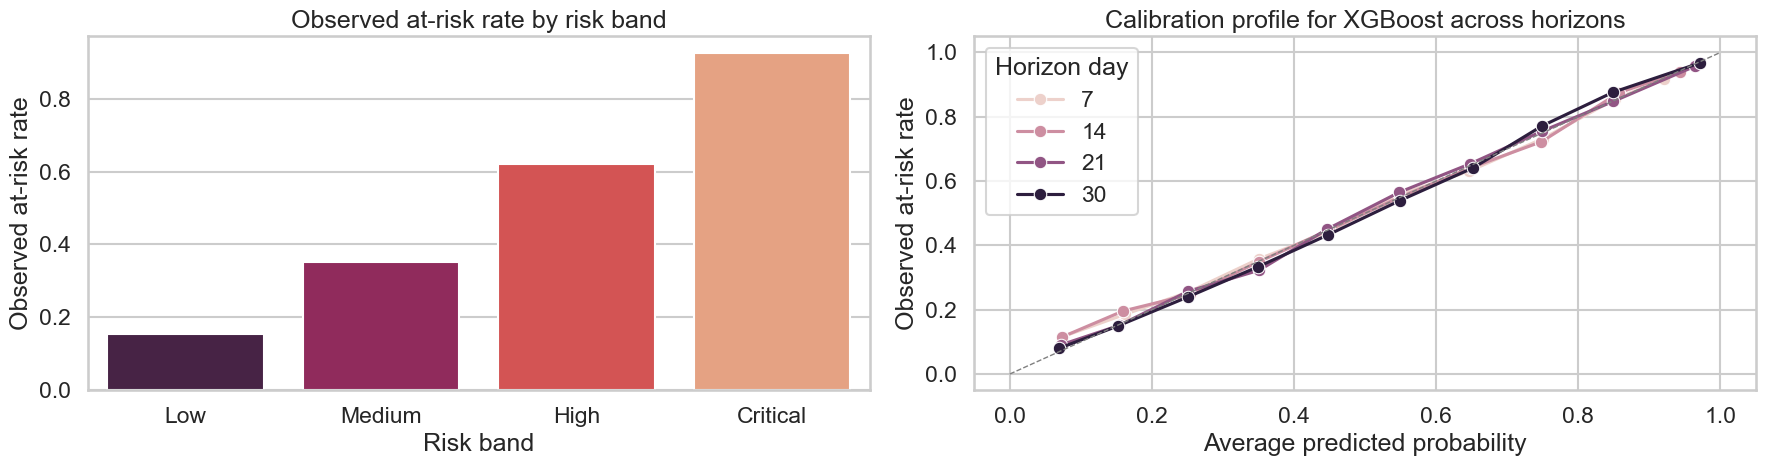

In [6]:
display(results.risk_band_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(data=results.risk_band_summary, x='risk_band', y='actual_at_risk_rate', palette='rocket', ax=axes[0])
axes[0].set_title('Observed at-risk rate by risk band')
axes[0].set_xlabel('Risk band')
axes[0].set_ylabel('Observed at-risk rate')

calibration_plot = results.calibration_summary.copy()
sns.lineplot(data=calibration_plot, x='avg_predicted_probability', y='observed_at_risk_rate', hue='horizon_day', marker='o', ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
axes[1].set_title(f'Calibration profile for {champion_model} across horizons')
axes[1].set_xlabel('Average predicted probability')
axes[1].set_ylabel('Observed at-risk rate')
axes[1].legend(title='Horizon day')

plt.tight_layout()

## 5. Ablation study

Ablation is run on `day 14` and `day 30` to answer a sharper research question:
**which feature group creates most of the value, and how does that change when the model sees more course history?**

,horizon_day,model,feature_group,feature_count,selected_threshold,validation_precision,validation_recall,validation_f2,validation_roc_auc,validation_pr_auc,test_precision,test_recall,test_f2,test_roc_auc,test_pr_auc
2,14,XGBoost,assessment only,7,0.5500,0.5527,0.9503,0.8308,0.5452,0.5539,0.5551,0.9526,0.8333,0.5494,0.5561
0,14,XGBoost,demographics only,20,0.3500,0.5485,0.9529,0.8305,0.6543,0.6735,0.5485,0.9492,0.8282,0.6512,0.6666
3,14,XGBoost,engagement + assessment,14,0.3000,0.5711,0.9311,0.8269,0.7185,0.7470,0.5776,0.9372,0.8335,0.7443,0.7689
1,14,XGBoost,engagement only,7,0.3000,0.5660,0.9335,0.8262,0.7076,0.7397,0.5669,0.9425,0.8322,0.7313,0.7583
4,14,XGBoost,full feature set,35,0.2500,0.5794,0.9372,0.8342,0.7666,0.8012,0.5853,0.9480,0.8435,0.7837,0.8114
7,30,XGBoost,assessment only,7,0.2500,0.5864,0.9425,0.8404,0.7382,0.7216,0.5902,0.9468,0.8447,0.7629,0.7431
5,30,XGBoost,demographics only,20,0.3500,0.5485,0.9529,0.8305,0.6543,0.6735,0.5485,0.9492,0.8282,0.6512,0.6666
8,30,XGBoost,engagement + assessment,14,0.2500,0.6075,0.9285,0.8398,0.7967,0.8260,0.6192,0.9422,0.8532,0.8240,0.8472
6,30,XGBoost,engagement only,7,0.3000,0.5820,0.9012,0.8121,0.7428,0.7860,0.5906,0.9146,0.8242,0.7662,0.8033
9,30,XGBoost,full feature set,35,0.2500,0.6278,0.9253,0.8452,0.8302,0.8639,0.6313,0.9367,0.8540,0.8467,0.8766


,horizon_day,feature_group,delta_test_precision_vs_full,delta_test_recall_vs_full,delta_test_f2_vs_full,delta_test_roc_auc_vs_full,delta_test_pr_auc_vs_full
2,14,assessment only,-0.0302,0.0046,-0.0102,-0.2343,-0.2553
0,14,demographics only,-0.0368,0.0012,-0.0153,-0.1325,-0.1449
3,14,engagement + assessment,-0.0077,-0.0107,-0.0100,-0.0393,-0.0425
1,14,engagement only,-0.0184,-0.0055,-0.0112,-0.0524,-0.0531
4,14,full feature set,0.0000,0.0000,0.0000,0.0000,0.0000
7,30,assessment only,-0.0411,0.0102,-0.0093,-0.0837,-0.1335
5,30,demographics only,-0.0828,0.0125,-0.0259,-0.1955,-0.2100
8,30,engagement + assessment,-0.0120,0.0055,-0.0008,-0.0226,-0.0294
6,30,engagement only,-0.0407,-0.0221,-0.0299,-0.0805,-0.0733
9,30,full feature set,0.0000,0.0000,0.0000,0.0000,0.0000


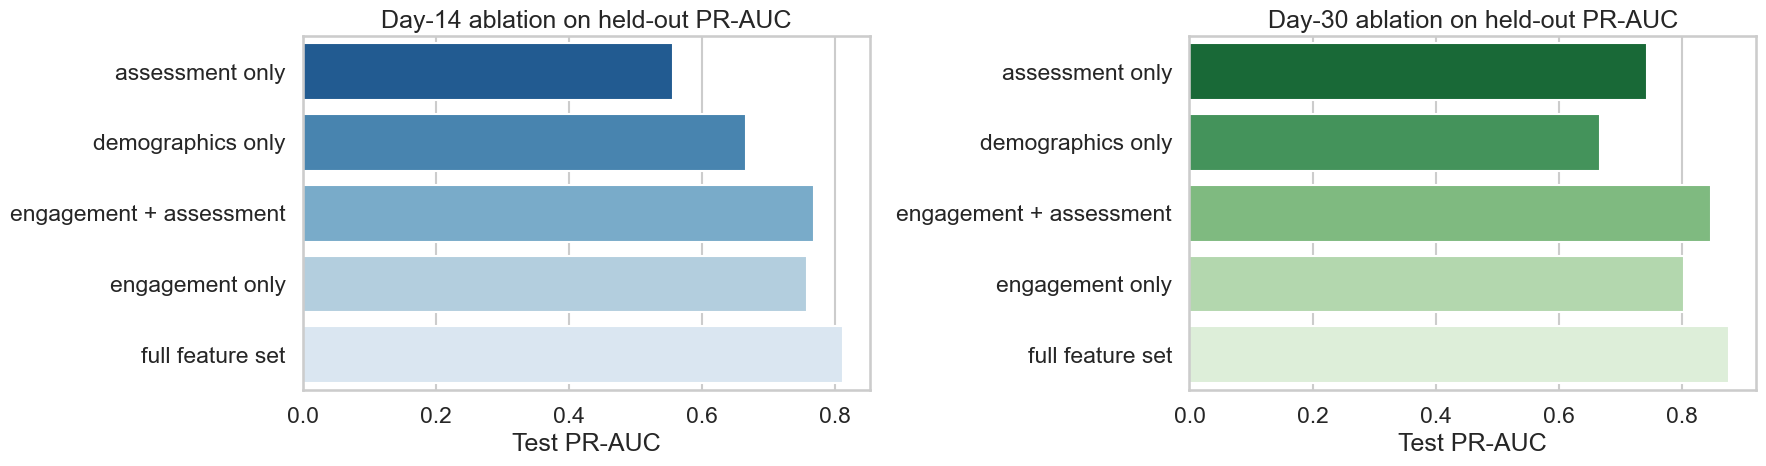

In [7]:
display(results.ablation_results.sort_values(['horizon_day', 'feature_group']))

ablation_plot = results.ablation_results.copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=ablation_plot.loc[ablation_plot['horizon_day'].eq(14)], x='test_pr_auc', y='feature_group', palette='Blues_r', ax=axes[0])
axes[0].set_title('Day-14 ablation on held-out PR-AUC')
axes[0].set_xlabel('Test PR-AUC')
axes[0].set_ylabel('')

sns.barplot(data=ablation_plot.loc[ablation_plot['horizon_day'].eq(30)], x='test_pr_auc', y='feature_group', palette='Greens_r', ax=axes[1])
axes[1].set_title('Day-30 ablation on held-out PR-AUC')
axes[1].set_xlabel('Test PR-AUC')
axes[1].set_ylabel('')

plt.tight_layout()

display(results.ablation_gain_summary[['horizon_day', 'feature_group', 'delta_test_precision_vs_full', 'delta_test_recall_vs_full', 'delta_test_f2_vs_full', 'delta_test_roc_auc_vs_full', 'delta_test_pr_auc_vs_full']].sort_values(['horizon_day', 'feature_group']))

## 6. Global interpretation and error diagnostics

The project keeps interpretation deliberately light and defensible:
- native importance from the champion model,
- permutation importance on validation ranking quality,
- concrete false-positive / false-negative inspection.

,feature,native_importance,permutation_importance_mean,permutation_importance_std,original_feature_name,horizon_day,model,importance_rank
0,avg_score,0.0806,0.0459,0.0027,avg_score,30,XGBoost,1
1,studied_credits,0.0606,0.0368,0.0024,studied_credits,30,XGBoost,2
2,days_since_last,0.2118,0.0367,0.0034,days_since_last,30,XGBoost,3
3,avg_submission_delay,0.0356,0.0173,0.0011,avg_submission_delay,30,XGBoost,4
4,assessment_discipline,0.0324,0.0105,0.0006,assessment_discipline,30,XGBoost,5
5,highest_education_Lower_Than_A_Level,0.0447,0.0079,0.0007,highest_education_Lower Than A Level,30,XGBoost,6
6,active_days_log,0.0900,0.0057,0.0009,active_days_log,30,XGBoost,7
7,gender_M,0.0281,0.0043,0.0004,gender_M,30,XGBoost,8
8,completion_ratio,0.0524,0.0034,0.0005,completion_ratio,30,XGBoost,9
9,num_of_prev_attempts,0.0190,0.0030,0.0005,num_of_prev_attempts,30,XGBoost,10


,id_student,code_module,code_presentation,horizon_day,model,selected_threshold,y_true,risk_probability,y_pred,risk_band,risk_band_method,final_result,cluster_label,rule_segment,recommended_path,action_1,action_2,action_3,recommendation_score,prediction_outcome,days_since_last,avg_score,avg_submission_delay,completion_ratio,num_submitted,total_clicks_log,active_days_log,early_engagement_ratio,assessment_discipline,persistence_score,learning_risk_index,distance_to_threshold
0,684936,DDD,2014J,30,XGBoost,0.2500,1,0.2495,0,Low,fixed_cutpoints,Fail,Steady Progressors,Steady Progressors,Assessment Recovery Path,Submit all available assessments in the first ...,Spread study activity across more days each we...,Follow a fixed weekly assessment schedule and ...,80.4000,False Negative,1.0000,75.0000,0.0000,0.5000,1.0000,5.5094,2.5649,0.5203,0.2846,0.4138,0.5882,-0.0005
1,591746,FFF,2014J,30,XGBoost,0.2500,1,0.2489,0,Low,fixed_cutpoints,Withdrawn,Focused Achievers,Focused Achievers,Early Start Path,Move more of your study activity into the firs...,Spread study activity across more days each we...,Prioritize accuracy and revision quality befor...,73.4000,False Negative,0.0000,72.0000,111.0000,1.0000,2.0000,5.8111,2.6391,0.1171,0.7481,0.4333,0.5607,-0.0011
2,483108,CCC,2014J,30,XGBoost,0.2500,1,0.2486,0,Low,fixed_cutpoints,Fail,Steady Progressors,Steady Progressors,Assessment Recovery Path,Submit all available assessments in the first ...,Follow a fixed weekly assessment schedule and ...,Move more of your study activity into the firs...,77.5000,False Negative,7.0000,100.0000,-3.0000,0.3333,1.0000,5.8319,2.7081,0.3059,0.1955,0.5833,0.5105,-0.0014
3,653052,BBB,2014J,30,XGBoost,0.2500,1,0.2486,0,Low,fixed_cutpoints,Fail,Steady Progressors,Steady Progressors,Consistency Building Path,Spread study activity across more days each we...,Move more of your study activity into the firs...,Submit all available assessments in the first ...,70.5000,False Negative,0.0000,100.0000,11.0000,0.5000,1.0000,4.4188,1.9459,0.1829,0.3058,0.2222,0.5883,-0.0014
4,534647,GGG,2013J,30,XGBoost,0.2500,1,0.2472,0,Low,fixed_cutpoints,Fail,Sporadic Explorers,Sporadic Explorers,Assessment Recovery Path,Submit all available assessments in the first ...,NaN,NaN,76.0000,False Negative,2.0000,0.0000,1.0000,0.0000,0.0000,5.1299,2.5649,0.5417,0.0000,0.4138,0.8567,-0.0028
5,491874,DDD,2013J,30,XGBoost,0.2500,1,0.2472,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Focused Achievers,Consistency Building Path,Spread study activity across more days each we...,Move more of your study activity into the firs...,NaN,77.7000,False Negative,0.0000,86.0000,1.0000,1.0000,1.0000,5.9216,2.6391,0.3710,0.5365,0.4194,0.5264,-0.0028
6,634859,FFF,2014B,30,XGBoost,0.2500,1,0.2464,0,Low,fixed_cutpoints,Fail,Steady Progressors,Focused Achievers,Mastery Improvement Path,Prioritize accuracy and revision quality befor...,Spread study activity across more days each we...,Move more of your study activity into the firs...,77.5000,False Negative,0.0000,92.0000,1.0000,1.0000,1.0000,6.1463,3.0445,0.7768,0.5365,0.6667,0.4148,-0.0036
7,618137,BBB,2014B,30,XGBoost,0.2500,1,0.2463,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Steady Progressors,Focused Study Path,Use more focused study sessions on the days yo...,Move more of your study activity into the firs...,Submit all available assessments in the first ...,73.9000,False Negative,7.0000,70.0000,1.0000,0.5000,1.0000,4.1109,2.6391,0.3167,0.2865,0.6842,0.5762,-0.0037
8,29769,FFF,2013J,30,XGBoost,0.2500,1,0.2454,0,Low,fixed_cutpoints,Fail,Steady Progressors,Focused Achievers,Mastery Improvement Path,Prioritize accuracy and revision quality befor...,Spread study activity across more days each we...,Move more of your study activity into the firs...,80.9000,False Negative,0.0000,88.0000,2.0000,1.0000,1.0000,5.6630,2.8332,0.4460,0.5385,0.5333,0.4930,-0.0046
9,579685,FFF,2013J,30,XGBoost,0.2500,1,0.2447,0,Low,fixed_cutpoints,Fail,Steady Progressors,Focused Achi

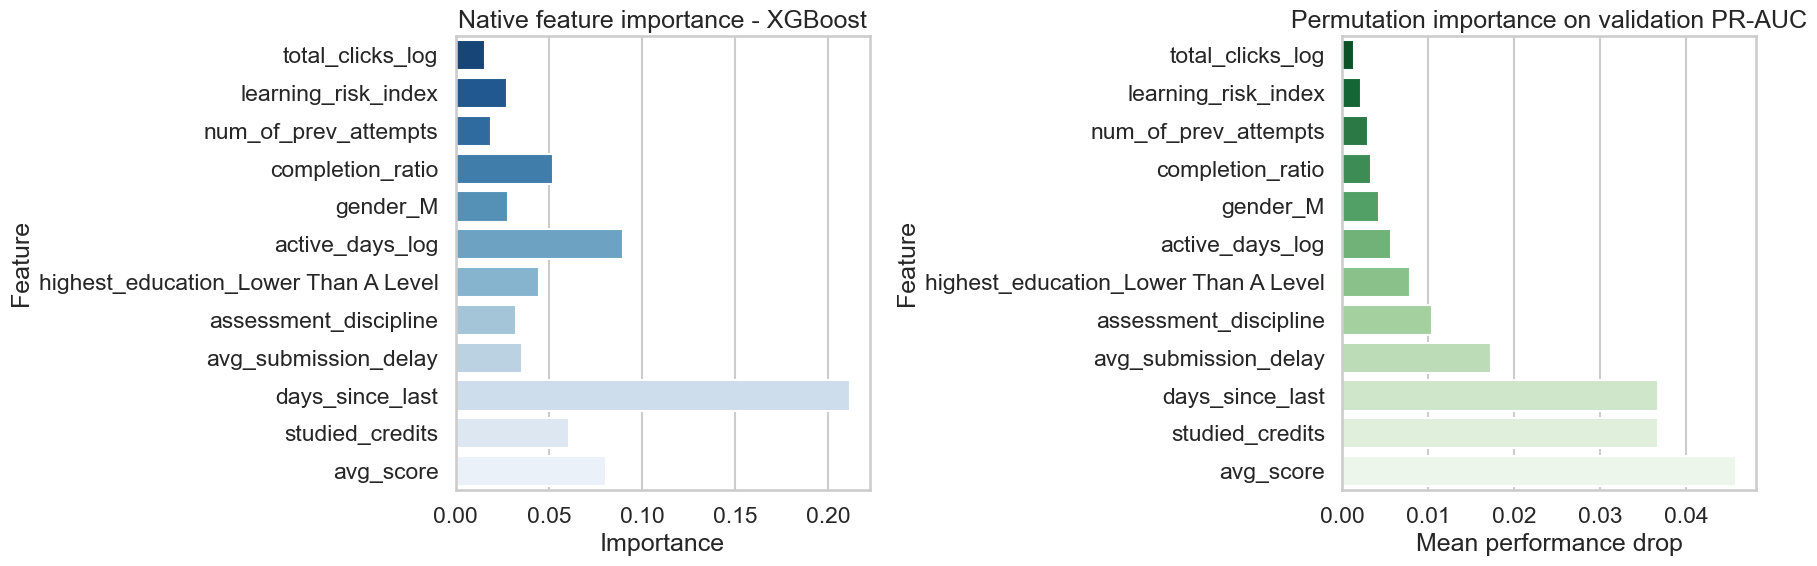

In [8]:
display(results.model_feature_importance.head(15))

top_importance = results.model_feature_importance.head(12).sort_values('permutation_importance_mean', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top_importance, x='native_importance', y='original_feature_name', palette='Blues_r', ax=axes[0])
axes[0].set_title(f'Native feature importance - {champion_model}')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

sns.barplot(data=top_importance, x='permutation_importance_mean', y='original_feature_name', palette='Greens_r', ax=axes[1])
axes[1].set_title('Permutation importance on validation PR-AUC')
axes[1].set_xlabel('Mean performance drop')
axes[1].set_ylabel('Feature')

plt.tight_layout()

display(results.error_analysis_samples.head(20))

## 7. Segment and outcome diagnostics for the dashboard

Even though segmentation is no longer a modeling input, it still remains useful for diagnostic slicing and Power BI storytelling.

,cluster_label,n,actual_at_risk_rate,predicted_positive_rate,average_risk_probability,precision,recall,accuracy
1,Inactive Drop-offs,"1,015.0000",0.9300,1.0000,0.9382,0.9300,1.0000,0.9300
2,Sporadic Explorers,"1,683.0000",0.6156,0.9210,0.6255,0.6535,0.9778,0.6673
3,Steady Progressors,"3,400.0000",0.3885,0.6859,0.3910,0.5000,0.8827,0.6115
0,Focused Achievers,421.0000,0.3349,0.4988,0.3171,0.4810,0.7163,0.6461


,final_result,n,predicted_positive_rate,average_risk_probability
0,Distinction,601,0.4176,0.2560
1,Pass,2476,0.6591,0.3613
2,Fail,1425,0.9165,0.6082
3,Withdrawn,2017,0.9509,0.7699


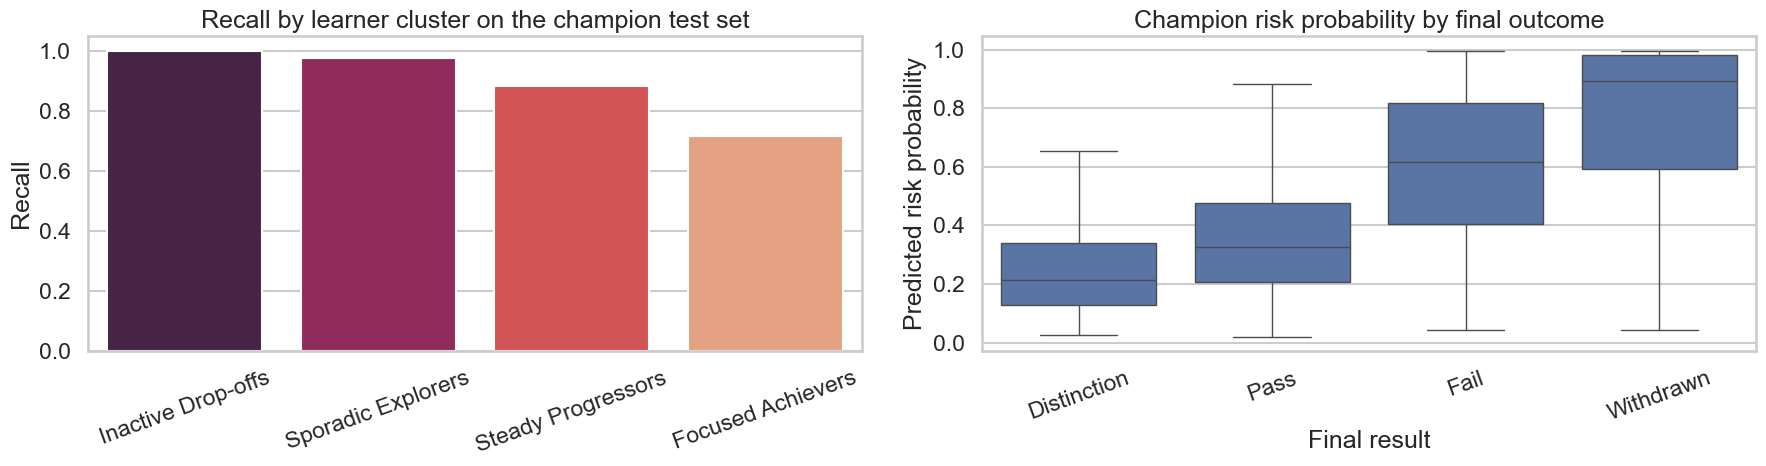

In [9]:
display(results.segment_model_performance)
display(results.outcome_risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=results.segment_model_performance, x='cluster_label', y='recall', palette='rocket', ax=axes[0])
axes[0].set_title('Recall by learner cluster on the champion test set')
axes[0].set_xlabel('')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=results.champion_test_predictions, x='final_result', y='risk_probability', order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], showfliers=False, ax=axes[1])
axes[1].set_title('Champion risk probability by final outcome')
axes[1].set_xlabel('Final result')
axes[1].set_ylabel('Predicted risk probability')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

## 8. Export handoff

This notebook now exports the full research artifact set required by the upgraded plan:

- `model_horizon_comparison.csv`
- `threshold_search_by_horizon.csv`
- `selected_operating_points.csv`
- `champion_test_predictions.csv`
- `champion_test_metrics.csv`
- `ablation_results.csv`
- `ablation_gain_summary.csv`
- `calibration_summary.csv`
- `risk_band_summary.csv`
- `risk_band_test_predictions.csv`
- `model_feature_importance.csv`
- `error_analysis_samples.csv`

The project can now defend a stronger research narrative:
**early warning is time-sensitive, behavioral plus assessment features dominate weaker baselines, and probability calibration matters because intervention decisions depend on risk tiers rather than only hard class labels.**